## Setup Libraries

In [1]:
!pip install -q pytabkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 6.4 MB/s eta 0:00:00


In [2]:
try:
    import xgboost
except:
    !pip install -q xgboost
    import xgboost

try:
    import lightgbm
except:
    !pip install -q lightgbm
    import lightgbm

try:
    import catboost
except:
    !pip install -q catboost
    import catboost

try:
    from colorama import Fore, Style
except:
    !pip install -q colorama
    from colorama import Fore, Style

In [3]:
import random
import warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from colorama import Fore, Style
from importlib.metadata import version
from time import time

from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import KBinsDiscretizer, TargetEncoder
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

import torch
import pytabkit
from pytabkit import XGB_TD_Classifier, LGBM_TD_Classifier, CatBoost_TD_Classifier

warnings.filterwarnings('ignore')
print("PyTorch  version:", torch.__version__)
print("PyTabKit version:", version("pytabkit"))

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
seed_everything(42)

PyTorch  version: 2.11.0+cpu
PyTabKit version: 1.7.3


## Load Data

In [4]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e10/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")

    ORIG_PATH = "/kaggle/input/datasets/arseniyshutko/binary-aviation-satisfaction-129k/"
    orig = pd.read_csv(ORIG_PATH+"data.csv")
elif PLATFORM == "colab":
    from google.colab import drive
    drive.mount("/content/drive")

    PATH   = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e10 | Airline Satisfaction/_airline_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train  = pd.read_csv(PATH+"train.csv")
    test   = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"data.csv")

# if torch.cuda.is_available():
#     submit = cudf.DataFrame(submit)
#     train = cudf.DataFrame(train)
#     test = cudf.DataFrame(test)
#     orig = cudf.DataFrame(orig)

## =================================================================================

for (name, df) in {"Train": train, "Test": test, 'Orig': orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nFrame type: {type(train)}")

Train shape: (699635, 23)
Test shape: (299844, 22)
Orig shape: (129880, 22)

Frame type: <class 'pandas.core.frame.DataFrame'>


## Preprocess Features

In [5]:
# %%time
# ID = 'id'
# TARGET = 'Will_Buy_EV'
# train[TARGET] = train[TARGET].map({'No': 0, 'Yes': 1})
# orig[TARGET] = orig[TARGET].map({'No': 0, 'Yes': 1})
# X = train.drop([ID, TARGET], axis=1); train_id = train[ID]
# y = train[TARGET]
# X_test = test.drop([ID], axis=1); test_id = test[ID]
# del train, test
# print("X      init shape:", X.shape)
# print("X_test init shape:", X_test.shape, "\n")

# cat_cols = X.select_dtypes(include=['object']).columns.tolist()
# num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
# print("init len(cat_cols):", len(cat_cols))
# print("init len(num_cols):", len(num_cols), "\n")

# category_map = {}
# important_combos = [
#     ('Annual_Income_USD', 'Range_Anxiety_Level'),
#     ('Age', 'Range_Anxiety_Level'),
#     ('Annual_Income_USD', 'Income_/_100_floor_'),
# ]
# def feature_engineering(df, fit=False):
#     # Fill NaNs
#     for col in cat_cols:
#         df[col] = df[col].fillna("missing")
#     for col in num_cols:
#         df[col] = df[col].fillna(0.0)

#     # Categorize string cats
#     for col in cat_cols:
#         if fit:
#             codes, uniques = df[col].factorize()
#             category_map[col] = uniques
#         else:
#             uniques = category_map[col]
#             code_map = {cat: i for i, cat in enumerate(uniques)}
#             codes = df[col].map(code_map).fillna(-1).astype('int32')
#         df[col] = codes
#         df[col] = df[col].astype('category')

#     # Arithmetic interaction
#     df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1e-6)).astype('float32')
#     df['Income_/_100_floor_']  = np.floor(df['Annual_Income_USD'] / 100.0).astype('float32').astype('category')
#     df['Income_/_1000_floor_']  = np.floor(df['Annual_Income_USD'] / 1000.0).astype('float32').astype('category')
#     df['Income_/_10000_floor_']  = np.floor(df['Annual_Income_USD'] / 10000.0).astype('float32').astype('category')
#     df['Daily_km_/_5_floor_']  = np.floor(df['Daily_Commute_km'] / 5.0).astype('float32').astype('category')

#     # Categorize numericals
#     for col in [i for i in num_cols if i not in ['Annual_Income_USD', 'Charging_Stations_Near_Home']]:
#         cat_name = f"{col}_cat_"
#         if fit:
#             codes, uniques = np.floor(df[col]).factorize()
#             category_map[col] = uniques
#         else:
#             uniques = category_map[col]
#             code_map = {cat: i for i, cat in enumerate(uniques)}
#             codes = np.floor(df[col]).map(code_map).fillna(-1).astype('int32')
#         df[cat_name] = codes
#         df[cat_name] = df[cat_name].astype('category')

#     # Digit extraction
#     for col in ['Daily_Commute_km']:
#         decimal_name = f"_{col}_decimal"
#         df[decimal_name] = (df[col] % 1).round(2).astype('float32')
#     df['Annual_Income_USD_is_multiple_10_'] = (np.floor(df['Annual_Income_USD']) % 10 == 0).astype('category')

#     # Target encoding from orig
#     for col in ['Annual_Income_USD']:
#         orig_enc_name = f"_{col}_mean_target_orig"
#         df[orig_enc_name] = (
#             df[col]
#             .map(orig.groupby(col)[TARGET].mean())
#             .fillna(orig[TARGET].mean())
#             .astype('float32')
#         )

#     # Count encoding
#     for col in ['Annual_Income_USD']:
#         count_name = f"_{col}_count"
#         if fit:
#             count_map = df[col].value_counts()
#             category_map[count_name] = count_map
#         else:
#             count_map = category_map[count_name]
#         df[count_name] = df[col].astype(object).map(count_map).fillna(0).astype('int32')

#     # Discretize numericals
#     bin_config = {'Annual_Income_USD': [400, 600, 800, 900, 1100]}
#     for col, bins_list in bin_config.items():
#         for n_bins in bins_list:
#             for strategy in ['quantile']:
#                 bin_name = f"{col}_{n_bins}_{strategy}_bin_"
#                 if fit:
#                     kb = KBinsDiscretizer(
#                         n_bins=n_bins,
#                         encode='ordinal',
#                         strategy=strategy,
#                         subsample=None
#                     )
#                     binned = kb.fit_transform(df[[col]]).ravel().astype('int32')
#                     category_map[bin_name] = kb
#                 else:
#                     kb = category_map[bin_name]
#                     binned = kb.transform(df[[col]]).ravel().astype('int32')
#                 df[bin_name] = binned
#                 df[bin_name] = df[bin_name].astype('category')

#     # Create interaction categories
#     combo_names = []
#     for cols in important_combos:
#         combo_name = '_'.join(cols) + '_'
#         combo_names.append(combo_name)
#         combo_series = df[cols[0]].astype(str)
#         for col in cols[1:]:
#             combo_series = combo_series + '_' + df[col].astype(str)
#         if fit:
#             codes, uniques = pd.factorize(combo_series, sort=False)
#             category_map[combo_name] = uniques
#         else:
#             uniques = category_map[combo_name]
#             code_map = {cat: i for i, cat in enumerate(uniques)}
#             codes = combo_series.map(code_map).fillna(-1).astype('int32')
#         df[combo_name] = codes
#         df[combo_name] = df[combo_name].astype('category')   

#     new_cat_cols = [col for col in df.columns if col.endswith('_')]
#     new_num_cols = [col for col in df.columns if col.startswith('_')]
#     return df, new_cat_cols, new_num_cols, combo_names

# X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
# X_test, _, _, _ = feature_engineering(X_test, fit=False)
# cat_cols += new_cat_cols; num_cols += new_num_cols
# print("len(new_cat_cols):", len(new_cat_cols))
# print("len(new_num_cols):", len(new_num_cols), "\n")

# print("prep len(cat_cols):", len(cat_cols))
# print("prep len(num_cols):", len(num_cols), "\n")
# print("X      prep shape:", X.shape)
# print("X_test prep shape:", X_test.shape, "\n")

In [6]:
ID = 'id'
TARGET = 'satisfaction'
train[TARGET] = train[TARGET].map({False: 0, True: 1})
X = train.drop([ID, TARGET], axis=1); train_id = train[ID]
y = train[TARGET]
X_test = test.drop([ID], axis=1); test_id = test[ID]
del train, test
print("X      init shape:", X.shape)
print("X_test init shape:", X_test.shape, "\n")

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print("init len(cat_cols):", len(cat_cols))
print("init len(num_cols):", len(num_cols), "\n")

category_map = {}
important_combos = [
    ('Class', 'Type of Travel', 'Gender'),
    ('Class', 'Type of Travel', 'Age'),
    ('Flight Distance', 'Departure/Arrival time convenient'),
]
def feature_engineering(df, fit=False):
    # Fill NaNs
    for col in cat_cols:
        df[col] = df[col].fillna("missing")
    for col in num_cols:
        df[col] = df[col].fillna(0.0)
    
    # Categorize numericals
    for col in num_cols:
        cat_name = f"{col}_cat_"
        if fit:
            codes, uniques = df[col].factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = df[col].map(code_map).fillna(-1).astype('int32')
        df[cat_name] = codes
        df[cat_name] = df[cat_name].astype('category')

    # Count encoding
    for col in cat_cols + ['Leg room service']:
        count_name = f"_{col}_count"
        if fit:
            count_map = df[col].value_counts()
            category_map[count_name] = count_map
        else:
            count_map = category_map[count_name]
        df[count_name] = df[col].map(count_map).fillna(0).astype('int32')

    # Create interaction categories
    combo_names = []
    for cols in important_combos:
        combo_name = '_'.join(cols) + '_'
        combo_names.append(combo_name)
        combo_series = df[cols[0]].astype(str)
        for col in cols[1:]:
            combo_series = combo_series + '_' + df[col].astype(str)
        if fit:
            codes, uniques = pd.factorize(combo_series, sort=False)
            category_map[combo_name] = uniques
        else:
            uniques = category_map[combo_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = combo_series.map(code_map).fillna(-1).astype('int32')
        df[combo_name] = codes
        df[combo_name] = df[combo_name].astype('category') 

    new_cat_cols = [col for col in df.columns if col.endswith('_')]
    new_num_cols = [col for col in df.columns if col.startswith('_')]
    return df, new_cat_cols, new_num_cols, combo_names

X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
X_test, _, _, _ = feature_engineering(X_test, fit=False)
cat_cols += new_cat_cols; num_cols += new_num_cols
print("len(new_cat_cols):", len(new_cat_cols))
print("len(new_num_cols):", len(new_num_cols), "\n")

print("prep len(cat_cols):", len(cat_cols))
print("prep len(num_cols):", len(num_cols), "\n")
print("X      prep shape:", X.shape)
print("X_test prep shape:", X_test.shape, "\n")

X      init shape: (699635, 21)
X_test init shape: (299844, 21) 

init len(cat_cols): 4
init len(num_cols): 17 

len(new_cat_cols): 20
len(new_num_cols): 5 

prep len(cat_cols): 24
prep len(num_cols): 22 

X      prep shape: (699635, 46)
X_test prep shape: (299844, 46) 



## Config

In [7]:
class CFG:
    FOLDS = 5
    SEED = 42
    TE = True

xgb_m = XGB_TD_Classifier(**{
    'n_estimators': 10_000, # d=1000
    'max_depth': 7, # d=6
    'lr': 0.02, # d=0.08
    'subsample': 0.9, # d=0.65
    'colsample_bytree': 0.9, # d=0.9
    # # 'colsample_bylevel': 0.75, # d=0.9
    # 'alpha': 3.0,
    # 'reg_lambda': 0.1, # d=0.0
    'min_child_weight': 10, # d=5e-06
    # # 'max_bin': 1015, # d=256
    # # 'max_cat_to_onehot': 10,
    # # 'verbosity': 0,
    # # 'n_threads': os.cpu_count(),
    'val_metric_name': "1-auc_ovr",
    'random_state': 42,
})

lgb_m = LGBM_TD_Classifier(**{
    # 'n_estimators': 10_000, # d=1000
    # 'num_leaves': 63, # d=50
    'lr': 0.035, # d=0.04
    # -------------------------------
    # 'max_bin': 512, # d=255
    'min_data_in_leaf': 70, # d=40
    # -------------------------------
    'subsample': 0.9, # d=0.75
    'colsample_bytree': 0.3, # d=1.0
    # 'bagging_freq': 2, # d=1
    # -------------------------------
    # 'lambda_l1': 0.1,
    'lambda_l2': 0.001,
    'val_metric_name': "1-auc_ovr",
    'random_state': 42,
})

cat_bay = CatBoost_TD_Classifier(**{
    'bootstrap_type': "Bayesian",
    # -------------------------------
    'n_estimators': 10_000, # d=1000
    # 'max_depth': 6, # d=7
    'lr': 0.04, # d=0.08
    # 'max_bin': 512, # d=254
    # -------------------------------
    'l2_leaf_reg': 1.0, # d=1e-05
    # # 'leaf_estimation_iterations': 5, d=1
    # 'random_strength': 0.6, # d=0.8
    # -------------------------------
    # 'one_hot_max_size': 10, # d=15
    # 'verbosity': 0,
    'random_state': 42,
})

cat_ben = CatBoost_TD_Classifier(**{
    'bootstrap_type': "Bernoulli",
    'n_estimators': 10_000,
    # 'subsample': 0.8, # d=0.9
    # 'max_depth': 6,
    'lr': 0.04,
    # 'l2_leaf_reg': 0.1,
    # 'random_strength': 0.6,
    # 'one_hot_max_size': 10,
    # 'max_bin': 254,
    # 'verbosity': 0,
    'random_state': 42,
})

all_models = {
    # ('Pyrealmlp65', realmlp),     # GPU
    # ('Pytabm65', tabm),           # GPU
    # ('Pymlp_plr65', mlp_plr),     # GPU
    # ('Pymlp_rtd65', mlp_rtd),     # GPU
    # ('Pyresnet65', resnet_rtd),   # GPU
    'xgb': ('pytab_XGB', xgb_m),       # GPU | TPU
    'lgb': ('pytab_LGB', lgb_m),       # CPU
    'cat0': ('pytab_CATbay', cat_bay), # TPU
    'cat1': ('pytab_CATben', cat_ben), # TPU
}

print("🤖 Model parameters defined!")

all_models

🤖 Model parameters defined!


{'xgb': ('pytab_XGB',
  XGB_TD_Classifier(colsample_bytree=0.9, lr=0.02, max_depth=7,
                    min_child_weight=10, n_estimators=10000, random_state=42,
                    subsample=0.9, val_metric_name='1-auc_ovr')),
 'lgb': ('pytab_LGB',
  LGBM_TD_Classifier(colsample_bytree=0.3, lambda_l2=0.001, lr=0.035,
                     min_data_in_leaf=70, random_state=42, subsample=0.9,
                     val_metric_name='1-auc_ovr')),
 'cat0': ('pytab_CATbay',
  CatBoost_TD_Classifier(bootstrap_type='Bayesian', l2_leaf_reg=1.0, lr=0.04,
                         n_estimators=10000, random_state=42)),
 'cat1': ('pytab_CATben',
  CatBoost_TD_Classifier(bootstrap_type='Bernoulli', lr=0.04, n_estimators=10000,
                         random_state=42))}

## Train K-Fold

In [8]:
FOLDS = 5
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

ID = 'lgb'
model_name = all_models[ID][0]
print(f"\n🚀 Training {model_name} with {FOLDS } Folds", end=" | ")

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []

t0 = time()
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr = X.iloc[tr_idx].copy()
    X_val = X.iloc[val_idx].copy()
    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]
    X_tst = X_test.copy()  

    # Target encoding
    if CFG.TE:
        te_cols = combo_names
        TE = TargetEncoder(target_type='binary', cv=5, smooth='auto', random_state=42)
        tr_enc = TE.fit_transform(X_tr[te_cols], y_tr)
        va_enc = TE.transform(X_val[te_cols])
        ts_enc = TE.transform(X_tst[te_cols])

        te_names = [f"_{col}TE" for col in te_cols]
        X_tr[te_names]  = tr_enc
        X_val[te_names] = va_enc
        X_tst[te_names] = ts_enc

        combos_to_drop = ['Class_Type of Travel_Age_', 'Flight Distance_Departure/Arrival time convenient_']
        X_tr = X_tr.drop(columns=combos_to_drop)
        X_val = X_val.drop(columns=combos_to_drop)
        X_tst = X_tst.drop(columns=combos_to_drop)

    if fold == 1: print(f"train={X_tr.shape}, valid={X_val.shape}\n")
    print("#"*16)
    print(f"### Fold {fold}/{FOLDS} ...")
    print("#"*16)

    model = all_models[ID][1] #RealMLP_TD_Classifier(**params)
    
    seeder = 42 #+ (fold-1)
    model.random_state = seeder

    model.fit(X_tr, y_tr, X_val, y_val) #, cat_col_names=cat_cols

    val_preds = model.predict_proba(X_val)[:, 1]
    fold_test_preds = model.predict_proba(X_tst)[:, 1]

    oof_preds[val_idx] = val_preds
    test_preds += fold_test_preds / FOLDS

    fold_score = roc_auc_score(y_val, val_preds)
    fold_scores.append(fold_score)
    print(f"seed={seeder}", end=" | ")
    print(f"{Fore.YELLOW}{Style.BRIGHT}Fold {fold} | AUC: {fold_score:.6f}{Style.RESET_ALL}\n")
    torch.cuda.empty_cache()

## -- CV results --
fold_results = {}

print(f"\n{'='*50}")
print(f"{FOLDS}-FOLD CV: {model_name} | {X_tr.shape}")
print(f"{'='*50}")
for i, s in enumerate(fold_scores, 1):
    print(f" • Fold {i} AUC: {s:.6f}")
    fold_results[f'fold_{i}'] = s

## -- Final out-of-fold score --
oof_auc = np.round(roc_auc_score(y, oof_preds), 6)
avg_auc = np.round(np.mean(fold_scores), 6)
std_auc = np.round(np.std(fold_scores), 6)

print("-------------------------------------------------|")
print(f"OOF score: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print(f"AVG score: {Fore.BLUE}{Style.BRIGHT}{avg_auc} ± {std_auc}{Style.RESET_ALL}")
print("-------------------------------------------------|")
print(f"{((time()-t0)/60):.2f} mins\n")


🚀 Training pytab_LGB with 5 Folds | train=(559708, 47), valid=(139927, 47)

################
### Fold 1/5 ...
################
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
seed=42 | Fold 1 | AUC: 0.960761

################
### Fold 2/5 ...
################
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
seed=42 | Fold 2 | AUC: 0.959403

################
### Fold 3/5 ...
################
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
seed=42 |

In [9]:
# ==================================================
# 5-FOLD CV: pytab_LGB | (559708, 47)
# ==================================================
#  • Fold 1 AUC: 0.960650
#  • Fold 2 AUC: 0.959394
#  • Fold 3 AUC: 0.960966
#  • Fold 4 AUC: 0.960305
#  • Fold 5 AUC: 0.960434
# -------------------------------------------------|
# OOF score: 0.960345
# AVG score: 0.96035 ± 0.000528
# -------------------------------------------------|
# 10.03 mins

## Evaluation and Submission

In [10]:
n = f"{model_name}_{avg_auc}"

print("\n" + "="*25)
print(f"AUC: {Fore.YELLOW}{Style.BRIGHT}{n}{Style.RESET_ALL}")
print("="*25)

fold_df = pd.DataFrame.from_dict(fold_results, orient='index', columns=['score'])
print(fold_df.to_string())


AUC: pytab_LGB_0.960367
           score
fold_1  0.960761
fold_2  0.959403
fold_3  0.960955
fold_4  0.960360
fold_5  0.960356


In [11]:
submit[TARGET] = test_preds

submit.to_csv(f"submit_{n}.csv", index=False)
np.save(f"oof_{n}.npy", oof_preds)
np.save(f"test_{n}.npy", test_preds)

submit

,id,satisfaction
0,699635,0.187973
1,699636,0.885912
2,699637,0.905698
3,699638,0.058357
4,699639,0.039883
...,...,...
299839,999474,0.039988
299840,999475,0.046134
299841,999476,0.220873
299842,999477,0.022627


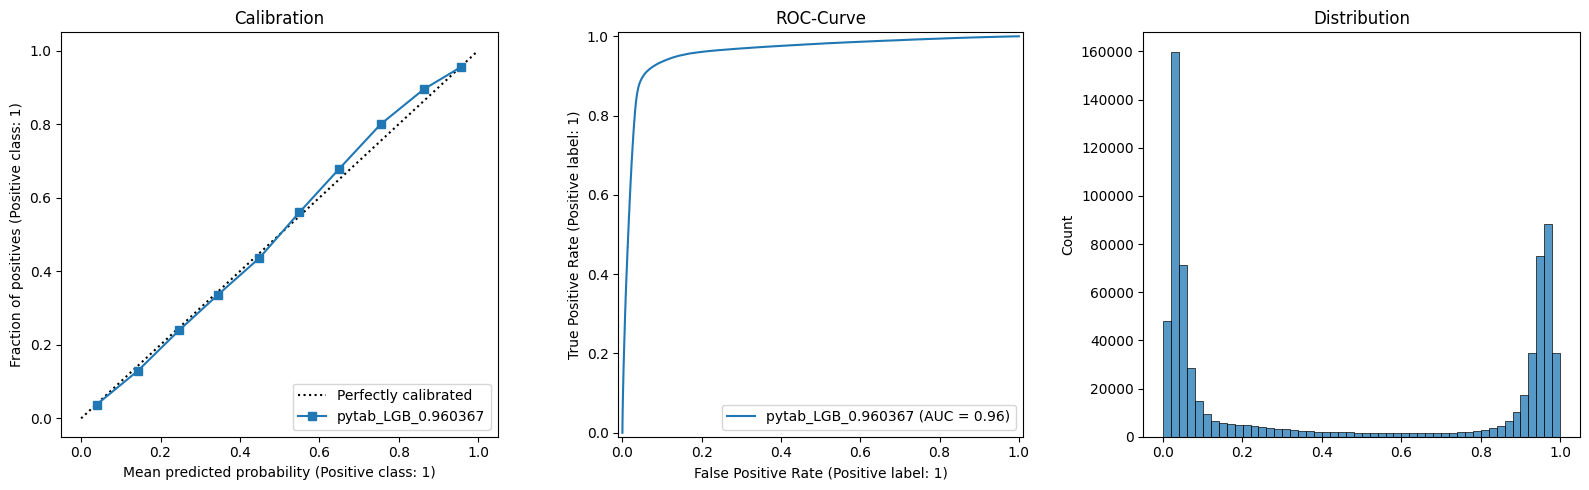

In [12]:
## -- Plot oof distributions --
_, axs = plt.subplots(1, 3, figsize=(16, 5)) 
CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=n, ax=axs[0])
axs[0].set_title(f"Calibration")

RocCurveDisplay.from_predictions(y, oof_preds, name=n, ax=axs[1])
axs[1].set_title(f"ROC-Curve")

sns.histplot(oof_preds, ax=axs[2], bins=50)
axs[2].set_title(f"Distribution")

plt.tight_layout()
plt.show()

print()

In [13]:
# !rm -r /kaggle/working